<a href="https://colab.research.google.com/github/Israel-Uriarte-G/Parcial-1/blob/main/Notebook_Proyecto_Optimizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png"
         width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Simulación Matemática - Prof. Luis Carlos Alvarado Garnica</i></h2>

---
# Notebook Proyecto Optimización
---



# Conjunto de datos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
import pandas as pd
from scipy import stats

Para esta actividad, se seleccionó un conjunto de datos que involucra el precio de casas en Holanda, el dataset contiene el precio de cada casa, el tamaño del lote, la superficie de área construida y el número de pisos.

In [ ]:
data = pd.read_excel('Datos_Casas.xlsx').dropna()
data.head()


,Price,Lot size (m2),Living space size (m2),Floors
0,525.0,251.0,135,3.0
1,425.0,181.0,109,3.0
2,575.0,198.0,138,3.0
3,259.5,231.0,92,3.0
4,1050.0,423.0,210,4.0


# Análisis exploratorio.

El primer paso fue hacer un análsis exploratorio de las variables para ver cómo se comportaban los datos con respecto al precio.

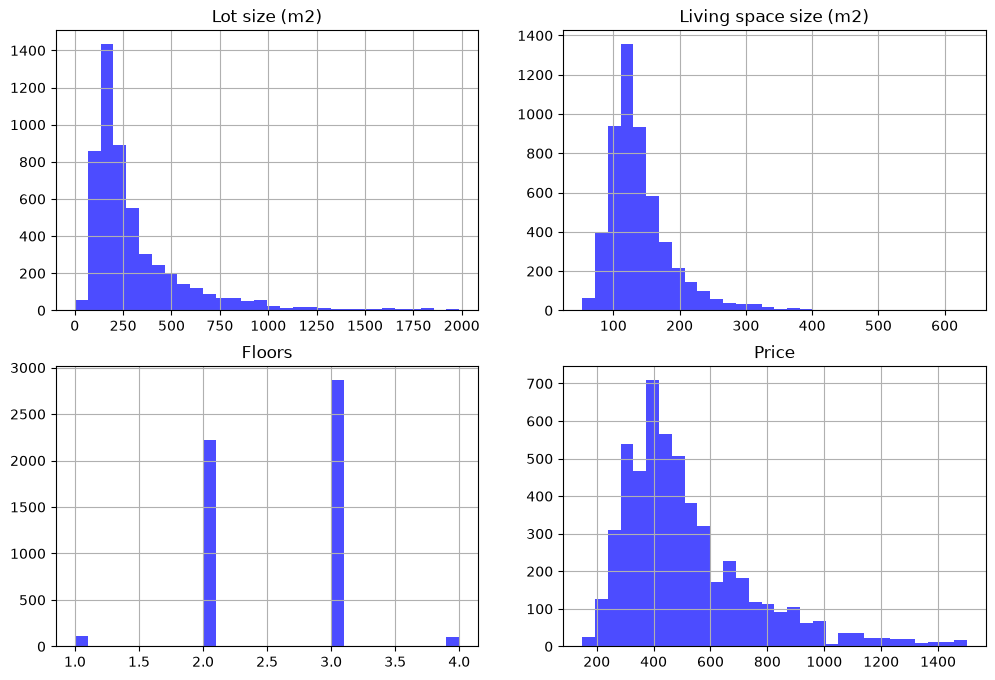

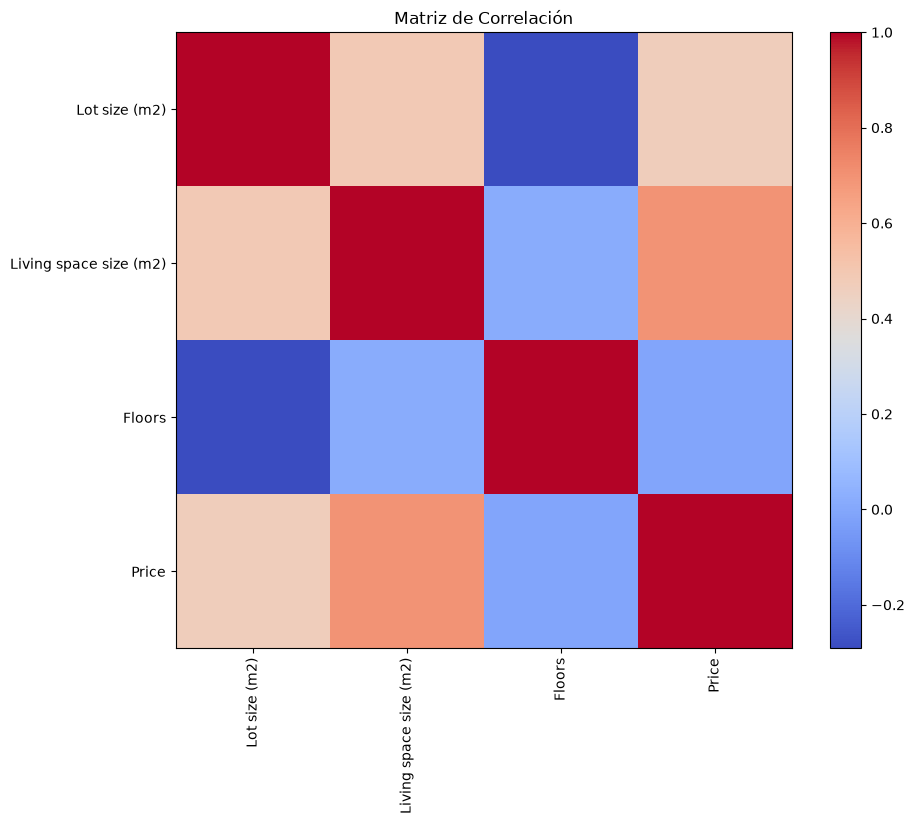

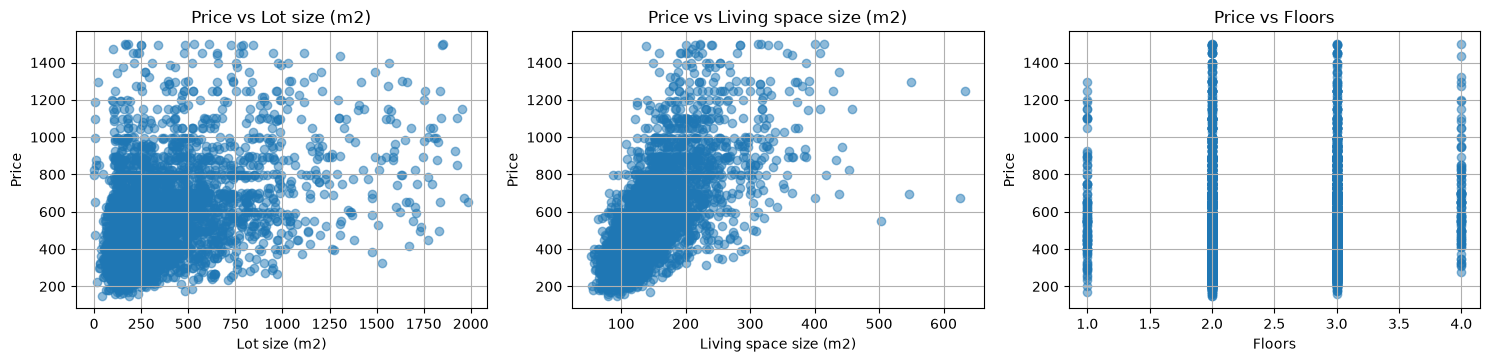

C:\Users\Luis PC\AppData\Local\Temp\ipykernel_6640\1429371912.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[column], vert=True)
C:\Users\Luis PC\AppData\Local\Temp\ipykernel_6640\1429371912.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[column], vert=True)
C:\Users\Luis PC\AppData\Local\Temp\ipykernel_6640\1429371912.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[column], vert=True)
C:\Users\Luis PC\AppData\Local\Temp\ipykernel_6640\1429371912.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'h

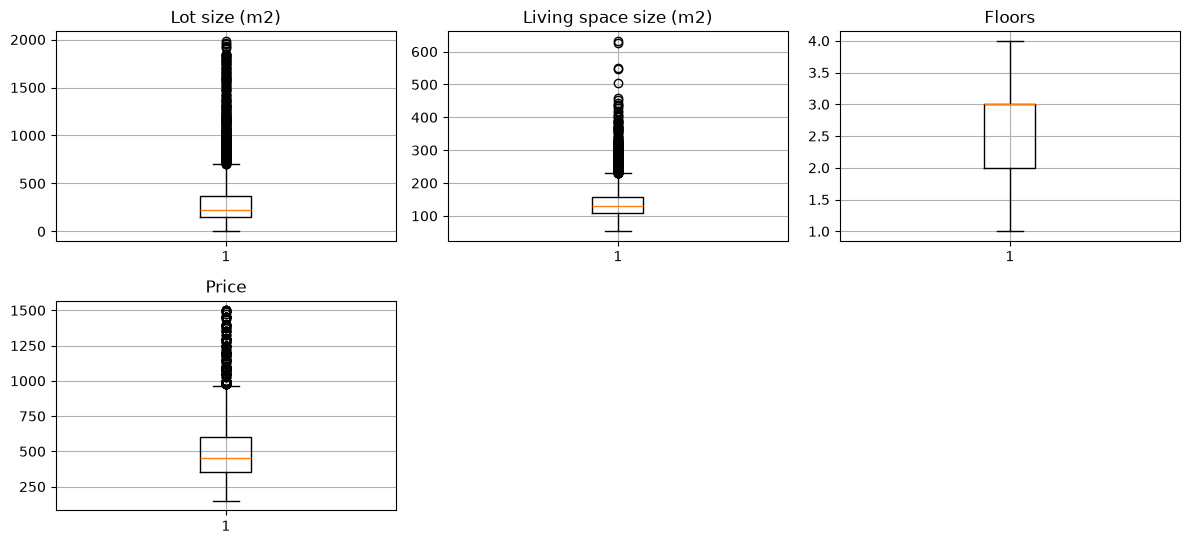

In [ ]:
subdata = data[["Lot size (m2)","Living space size (m2)","Floors","Price"]]

plt.figure(figsize=(12, 8))
for i, column in enumerate(subdata, 1):
    plt.subplot(2, 2, i)
    plt.hist(data[column], bins=30, color='blue', alpha=0.7)
    plt.title(column)
    plt.grid(True)

plt.figure(figsize=(10, 8))
correlation_matrix = subdata.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Matriz de Correlación')
plt.show()

plt.figure(figsize=(15, 10))
for i, column in enumerate(subdata.iloc[:,:-1], 1):
    plt.subplot(3, 3, i)
    plt.scatter(data[column], data['Price'], alpha=0.5)
    plt.title(f'Price vs {column}')
    plt.xlabel(column)
    plt.ylabel('Price')
    plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
for i, column in enumerate(subdata, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(data[column], vert=True)
    plt.title(column)
    plt.grid(True)
plt.tight_layout()
plt.show()


# Regresión lineal.

In [ ]:
class MiRegresionLineal:
    def __init__(self, X, y):
        self.X = np.c_[np.ones((X.shape[0], 1)), X]
        self.y = y
        self.theta = None

    def funcion_costo(self, theta):
        """Función de costo basada en mínimos cuadrados."""
        errores = self.y - self.X.dot(theta)
        return np.mean(errores ** 2)

    def fit(self):
        """Ajusta los coeficientes usando scipy.optimize.minimize."""
        theta_inicial = np.zeros(self.X.shape[1])
        resultado = minimize(self.funcion_costo, theta_inicial, method='BFGS')
        self.theta = resultado.x

    def visualizar(self):
        """Grafica los datos junto con la recta ajustada."""
        plt.scatter(self.X[:, 1], self.y, alpha=0.6)
        plt.plot(self.X[:, 1], self.X.dot(self.theta), color='red')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Ajuste de Regresión Lineal')
        plt.show()

    def predecir(self, X_nuevo):
        """Realiza una predicción para nuevos valores de entrada."""
        X_nuevo = np.c_[np.ones((X_nuevo.shape[0], 1)), X_nuevo]
        return X_nuevo.dot(self.theta)

    def mostrar_ecuacion(self):
        """Imprime la ecuación de la regresión lineal."""
        print(f'y = {self.theta[0]:.2f} + {self.theta[1]:.2f} X')

    def mostrar_metricas(self, y_real, y_pred):
        """Imprime métricas de evaluación del modelo."""
        mse = np.mean((y_real - y_pred) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_real - y_pred))
        ss_res = np.sum((y_real - y_pred) ** 2)
        ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
        r2 = 1 - ss_res / ss_tot

        print(f'R² (Coeficiente de determinación): {r2:.4f}')
        print(f'MSE (Error cuadrático medio): {mse:.4f}')
        print(f'RMSE (Raíz del error cuadrático medio): {rmse:.4f}')
        print(f'MAE (Error absoluto medio): {mae:.4f}')

En este punto, se definiero las 3 variables predictoras y la variable a predecir. Asimismo, se realizó una regresión lineal para cada variable para ver que tanto se aproximaban los datos.

In [ ]:
X1 = data[["Lot size (m2)"]].values
X2 = data[["Living space size (m2)"]].values
X3 = data[["Floors"]].values
y = data["Price"].values

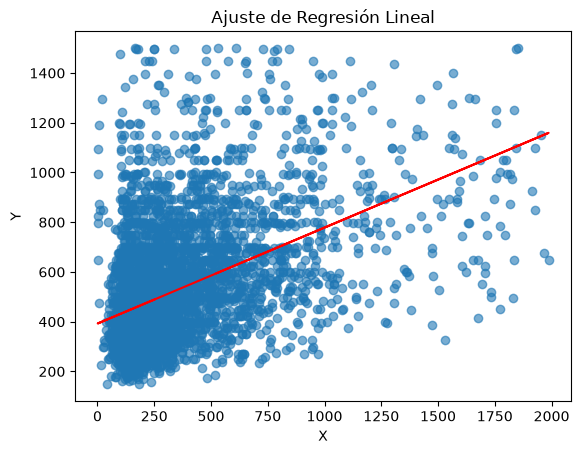

In [ ]:
modelo = MiRegresionLineal(X1, y)
modelo.fit()
modelo.visualizar()

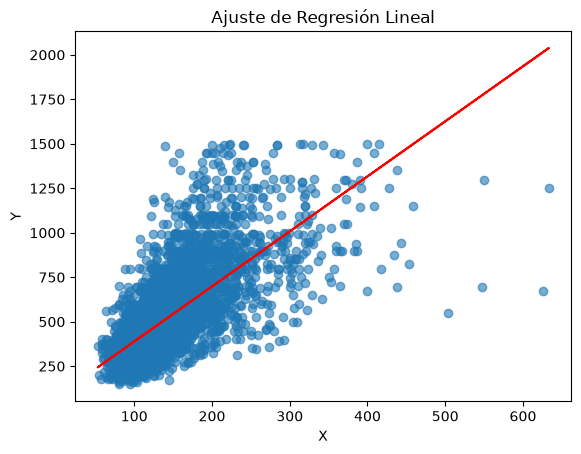

In [ ]:
modelo2 = MiRegresionLineal(X2, y)
modelo2.fit()
modelo2.visualizar()

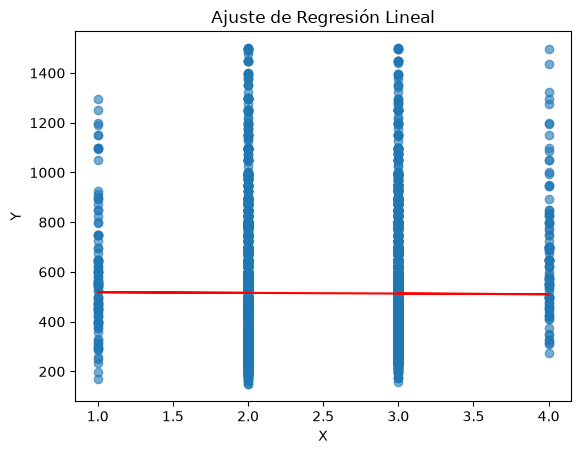

In [ ]:
modelo3 = MiRegresionLineal(X3, y)
modelo3.fit()
modelo3.visualizar()

De las 3 variables predictores, la que mejor se ajusta a una regresión lineal es el área, ya que los datos ahí tienen una mayor cercanía con la recta.

# Residuos de la regresión lineal.

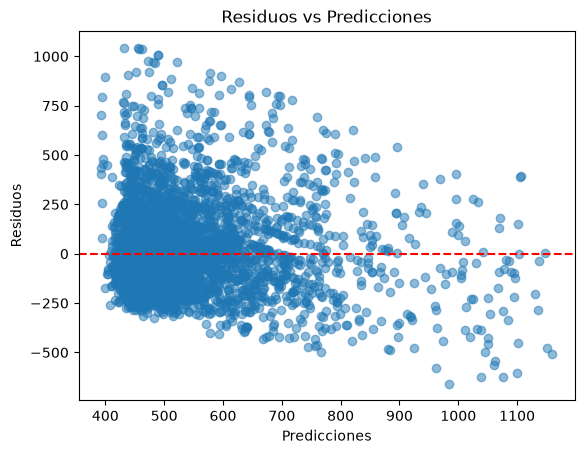

In [ ]:
predicciones1 = modelo.predecir(X1)
residuos1 = y.ravel() - predicciones1.ravel()
plt.scatter(predicciones1, residuos1, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')
plt.show()

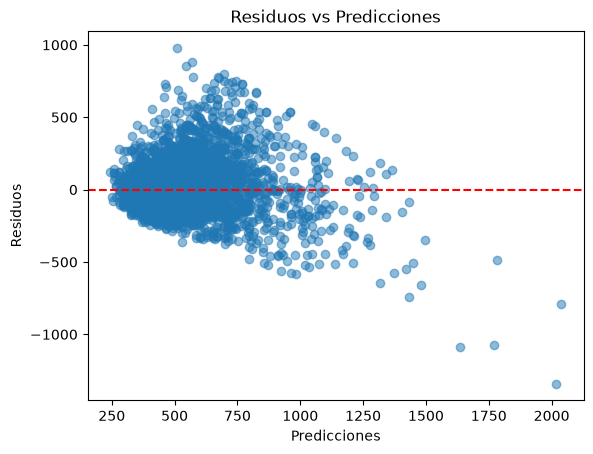

In [ ]:
predicciones2 = modelo2.predecir(X2)
residuos2 = y.ravel() - predicciones2.ravel()
plt.scatter(predicciones2, residuos2, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')
plt.show()

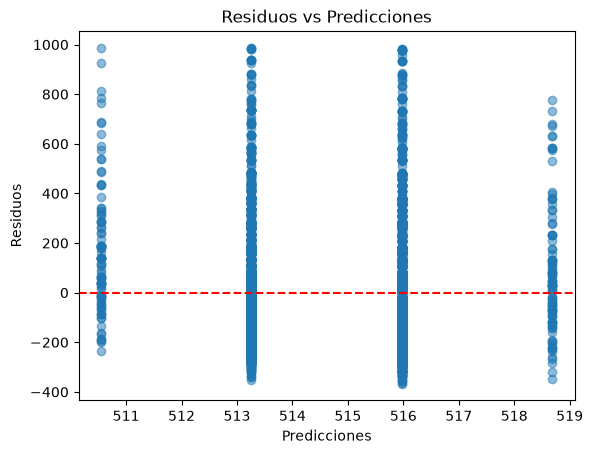

In [ ]:
predicciones3 = modelo3.predecir(X3)
residuos3 = y.ravel() - predicciones3.ravel()
plt.scatter(predicciones3, residuos3, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')
plt.show()

# Comprobación de los supuestos de factibilidad para regresión lineal.

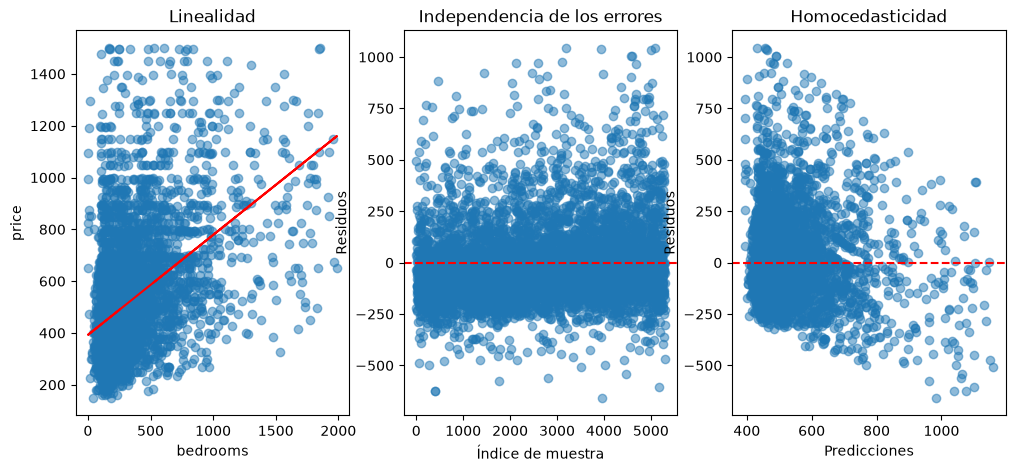

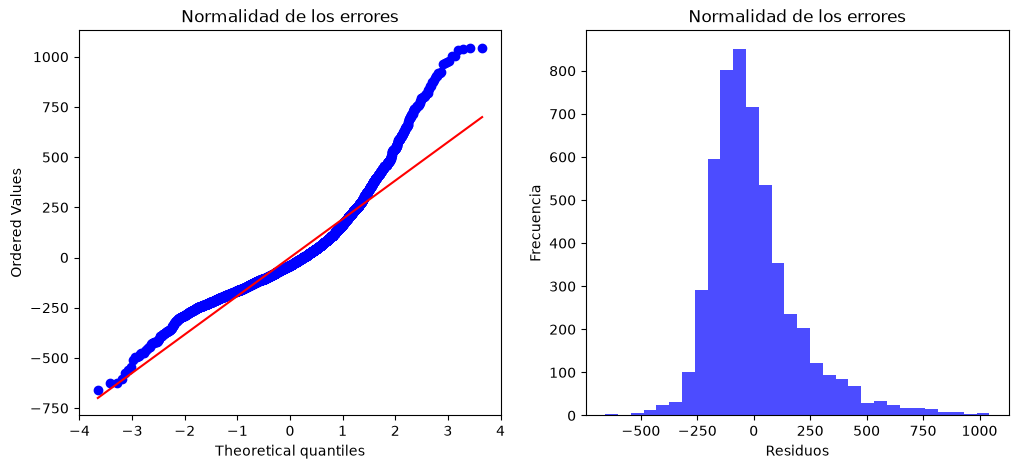

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.scatter(X1, y, alpha=0.5)
plt.plot(X1, modelo.predecir(X1), color='red')
plt.xlabel('bedrooms')
plt.ylabel('price')
plt.title('Linealidad')

plt.subplot(1, 3, 2)
plt.scatter(range(len(residuos1)), residuos1, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Índice de muestra')
plt.ylabel('Residuos')
plt.title('Independencia de los errores')

plt.subplot(1, 3, 3)
plt.scatter(predicciones1, residuos1, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Homocedasticidad')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(residuos1, dist="norm", plot=plt)
plt.title('Normalidad de los errores')
plt.subplot(1, 2, 2)
plt.hist(residuos1, bins=30, color='blue', alpha=0.7)
plt.title('Normalidad de los errores')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

En el caso de la variable "Lot size (m2)", puede decirse que cumple con el supuesto de linealidad, no se aprecian patrones en los errores, por lo que también cumple con la independencia de los errores, no obstante presenta heterocedasticidad muy marcada y la distribución de los errores asemeja a una normal pero se encuentra sesgada.


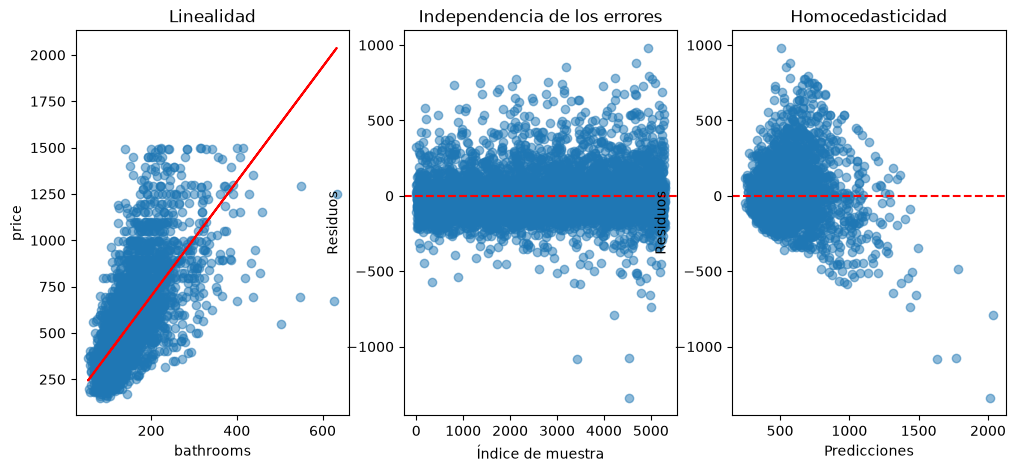

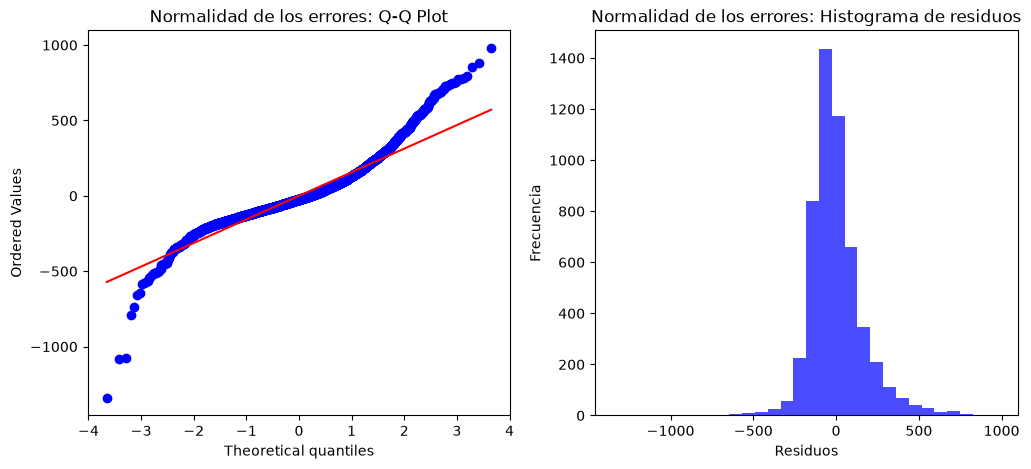

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.scatter(X2, y, alpha=0.5)
plt.plot(X2, modelo2.predecir(X2), color='red')
plt.xlabel('bathrooms')
plt.ylabel('price')
plt.title('Linealidad')

plt.subplot(1, 3, 2)
plt.scatter(range(len(residuos2)), residuos2, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Índice de muestra')
plt.ylabel('Residuos')
plt.title('Independencia de los errores')

plt.subplot(1, 3, 3)
plt.scatter(predicciones2, residuos2, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Homocedasticidad')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(residuos2, dist="norm", plot=plt)
plt.title('Normalidad de los errores: Q-Q Plot')
plt.subplot(1, 2, 2)
plt.hist(residuos2, bins=30, color='blue', alpha=0.7)
plt.title('Normalidad de los errores: Histograma de residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

La variable de "Living space size (m2)", cumple con la linealidad y con la independencia de los errores al no tener ningún patrón visible. Por otro lado, la variable presenta una heterocedasticidad no tan marcada en comparación con la variable anterior, finalmente los errores tienen una distribución leptocúrtica al tener un pico muy pronunciado.

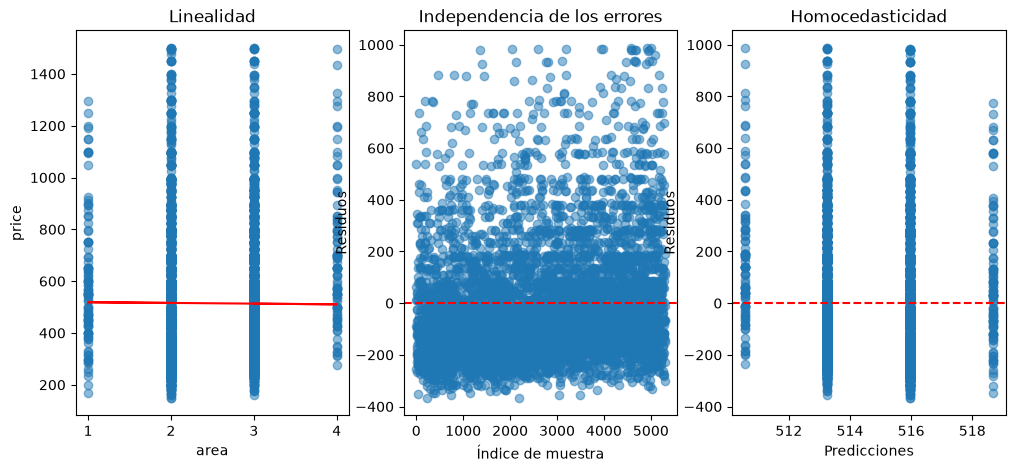

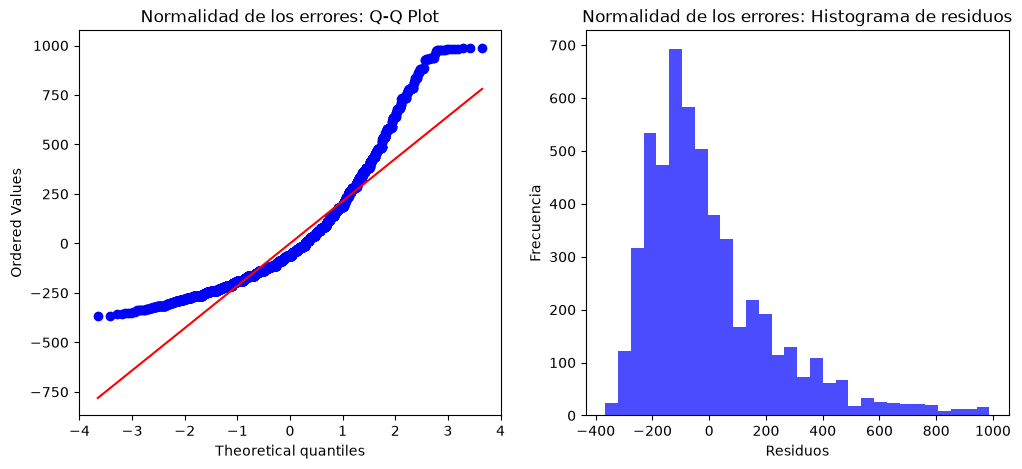

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.scatter(X3, y, alpha=0.5)
plt.plot(X3, modelo3.predecir(X3), color='red')
plt.xlabel('area')
plt.ylabel('price')
plt.title('Linealidad')

plt.subplot(1, 3, 2)
plt.scatter(range(len(residuos3)), residuos3, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Índice de muestra')
plt.ylabel('Residuos')
plt.title('Independencia de los errores')

plt.subplot(1, 3, 3)
plt.scatter(predicciones3, residuos3, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Homocedasticidad')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(residuos3, dist="norm", plot=plt)
plt.title('Normalidad de los errores: Q-Q Plot')
plt.subplot(1, 2, 2)
plt.hist(residuos3, bins=30, color='blue', alpha=0.7)
plt.title('Normalidad de los errores: Histograma de residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

Para la variable de "Floors", el supuesto de linealidad no se cumple, los errores si son independientes y no presentan un patrón definido. La variable presenta heterocedasticidad y la distribución de estos se encuentra sesgada.

# Métricas de error de los modelos.

In [ ]:
modelo.mostrar_ecuacion()
modelo.mostrar_metricas(y, predicciones1)

y = 392.50 + 0.39 X
R² (Coeficiente de determinación): 0.2205
MSE (Error cuadrático medio): 40399.7680
RMSE (Raíz del error cuadrático medio): 200.9969
MAE (Error absoluto medio): 145.9276


In [ ]:
modelo2.mostrar_ecuacion()
modelo2.mostrar_metricas(y, predicciones2)

y = 79.54 + 3.09 X
R² (Coeficiente de determinación): 0.4852
MSE (Error cuadrático medio): 26682.2516
RMSE (Raíz del error cuadrático medio): 163.3470
MAE (Error absoluto medio): 115.4109


In [ ]:
modelo3.mostrar_ecuacion()
modelo3.mostrar_metricas(y, predicciones3)

y = 521.39 + -2.71 X
R² (Coeficiente de determinación): 0.0000
MSE (Error cuadrático medio): 51825.0924
RMSE (Raíz del error cuadrático medio): 227.6513
MAE (Error absoluto medio): 171.1903


# Regresión lineal múltiple

Se tomo la decisión de realizar un modelo de regresión lineal simple para determinar si mejoraban las metricas de error. Las variables predictoras fueron X1 y X2.

In [ ]:
from sklearn.linear_model import LinearRegression
X_mult=data[["Lot size (m2)", "Living space size (m2)"]]
modelo4=LinearRegression()
modelo4.fit(X_mult, y)
print(f'Intercepto sklearn: {modelo4.intercept_}| Beta 1 sklearn: {modelo4.coef_[0]} | Beta 2 sklearn: {modelo4.coef_[1]}')

Intercepto sklearn: 87.35276386351029| Beta 1 sklearn: 0.13868493937173595 | Beta 2 sklearn: 2.7260317291470697


In [ ]:
y_pred_mul= 87.3528 + 0.1387*(data["Lot size (m2)"].values) + 2.7260*(data["Living space size (m2)"].values)


In [ ]:
mse_mult = np.mean((y - y_pred_mul) ** 2)
rmse_mult = np.sqrt(mse_mult)
mae_mult = np.mean(np.abs(y - y_pred_mul))
ss_res = np.sum((y - y_pred_mul) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2_mult = 1 - ss_res / ss_tot
print(f'R² (Coeficiente de determinación): {r2_mult:.4f}')
print(f'MSE (Error cuadrático medio): {mse_mult:.4f}')
print(f'RMSE (Raíz del error cuadrático medio): {rmse_mult:.4f}')
print(f'MAE (Error absoluto medio): {mae_mult:.4f}')

R² (Coeficiente de determinación): 0.5068
MSE (Error cuadrático medio): 25561.1555
RMSE (Raíz del error cuadrático medio): 159.8786
MAE (Error absoluto medio): 113.3068


### `Evalúa que tan bueno es tu modelo para predecir y realiza con ello tus conclusiones.`

De mis 3 modelos, el modelo que tuvo un mejor desempeño, fue el modelo que utiliza la variable de "Area", dado que tiene un R^2 de 0.5615, indicando que al menos el 56% de la variabilidad en la variable de "Price" puede ser explicada con esta variable. Asimismo el RMSE de 13,374.2597, tienen un error promedio de $13,400.00 en la escala de "Price", siendo el error más bajo de los 3 modelos.

#  Comparativa entre los modelos de regresión lineal simple y múltiple

In [ ]:
reg = LinearRegression()
reg.fit(X1, y)

reg_predicciones = reg.predict(X1)
reg_r2 = reg.score(X1, y)
reg_mse = np.mean((y - reg_predicciones) ** 2)
reg_rmse = np.sqrt(reg_mse)
reg_mae = np.mean(np.abs(y - reg_predicciones))

reg2 = LinearRegression()
reg2.fit(X2, y)
reg2_predicciones = reg2.predict(X2)
reg2_r2 = reg2.score(X2, y)
reg2_mse = np.mean((y - reg2_predicciones) ** 2)
reg2_rmse = np.sqrt(reg2_mse)
reg2_mae = np.mean(np.abs(y - reg2_predicciones))

reg3 = LinearRegression()
reg3.fit(X3, y)
reg3_predicciones = reg3.predict(X3)
reg3_r2 = reg3.score(X3, y)
reg3_mse = np.mean((y - reg3_predicciones) ** 2)
reg3_rmse = np.sqrt(reg3_mse)
reg3_mae = np.mean(np.abs(y - reg3_predicciones))

reg3_predicciones = reg3.predict(X3)
reg3_r2 = reg3.score(X3, y)
reg3_mse = np.mean((y - reg3_predicciones) ** 2)
reg3_rmse = np.sqrt(reg3_mse)
reg3_mae = np.mean(np.abs(y - reg3_predicciones))


pd.DataFrame({
    'Métrica': ['Ecuación', 'R²', 'MSE', 'RMSE', 'MAE'],
    'Modelo 1': [f'y = {reg.intercept_:.2f} + {reg.coef_[0]:.2f} X1',
                f'{reg_r2:.4f}', f'{reg_mse:.4f}', f'{reg_rmse:.4f}', f'{reg_mae:.4f}'],
    'Modelo 2': [f'y = {reg2.intercept_:.2f} + {reg2.coef_[0]:.2f} X2',
                f'{reg2_r2:.4f}', f'{reg2_mse:.4f}', f'{reg2_rmse:.4f}', f'{reg2_mae:.4f}'],
    'Modelo 3': [f'y = {reg3.intercept_:.2f} + {reg3.coef_[0]:.2f} X3',
                f'{reg3_r2:.4f}', f'{reg3_mse:.4f}', f'{reg3_rmse:.4f}', f'{reg3_mae:.4f}'],
    'Modelo 4': [f'y = {modelo4.intercept_:.2f} + {modelo4.coef_[0]:.2f} X1 +{modelo4.coef_[1]:.2f} X2',
                f'{r2_mult:.4f}', f'{mse_mult:.4f}', f'{rmse_mult:.4f}', f'{mae_mult:.4f}']
})


,Métrica,Modelo 1,Modelo 2,Modelo 3,Modelo 4
0,Ecuación,y = 392.50 + 0.39 X1,y = 79.54 + 3.09 X2,y = 521.39 + -2.71 X3,y = 87.35 + 0.14 X1 +2.73 X2
1,R²,0.2205,0.4852,0.0000,0.5068
2,MSE,40399.7680,26682.2516,51825.0924,25561.1555
3,RMSE,200.9969,163.3470,227.6513,159.8786
4,MAE,145.9276,115.4109,171.1903,113.3068


Comparando las métricas de error de los diferentes modelos de regresión lineal, puede llegarse a la conclusión de que las variables que mejor explican la variabilidad de los datos son "Lot size" con un R^2 de 0.22 y "Living space size" con un R^2 de 0.48. La peor variable claramente fue "Floors" con una R^2 de 0. La regresipon lineal múltiple tuvo las mejores métricas al explicar el 50% de la variabilidad de los datos y tener el menor error promedio de los 4 modelos con 159.87 miles de euros.